# SCC0957 — Prática de Ciências de Dados II: Dados da Dengue PySuS
* Vinícius de Moraes - 13749910
* Rômulo Ferreira da Silva - 13734326
* João Pedro Barbosa Madeira - 13683038
* Pedro Silva dos Santos - 12688431
* Thiago Pasquotto Tavares - 15490194

## Carregando as bibliotecas

In [1]:
!uv pip install pysus==1.0.1 -q
!uv pip install nbformat
!uv pip install plotly
!uv pip install matplotlib
!uv pip install geopandas

Checked 1 package in 3ms
Checked 1 package in 2ms
Checked 1 package in 6ms
Checked 1 package in 5ms


In [2]:
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.express as px
from pysus import SINAN
import polars as pl
import geopandas as gpd

## Carregando os dados

### 1. Carregando os Dados do SINAN

In [3]:
sinan = SINAN().load() # Loads the files from DATASUS
files = sinan.get_files(dis_code=["DENG"])
parquet = sinan.download(files)

22316488it [00:00, 2462566032.21it/s]       


In [4]:
df = pl.scan_parquet(
    [str(p) for p in parquet],
    extra_columns="ignore",
    missing_columns="insert"
)

In [5]:
df.collect_schema()

Schema([('ID_MUNICIP', String),
        ('ID_UNIDADE', String),
        ('DT_NOTIFIC', String),
        ('CS_RACA', String),
        ('CS_ESCOLAR', String),
        ('NU_ANO', String),
        ('SEM_NOT', String),
        ('SG_UF_NOT', String),
        ('ID_REGIONA', String),
        ('DT_SIN_PRI', String),
        ('SEM_PRI', String),
        ('NU_IDADE', String),
        ('CS_SEXO', String),
        ('ID_MN_RESI', String),
        ('ID_RG_RESI', String),
        ('SG_UF', String),
        ('ID_PAIS', String),
        ('ID_DG_NOT', String),
        ('ID_EV_NOT', String),
        ('ANT_DT_INV', String),
        ('OCUPACAO', String),
        ('DENGUE', String),
        ('ANO', String),
        ('VACINADO', String),
        ('DT_DOSE', String),
        ('FEBRE', String),
        ('DT_FEBRE', String),
        ('DURACAO', String),
        ('LACO', String),
        ('CEFALEIA', String),
        ('EXANTEMA', String),
        ('DOR', String),
        ('PROSTACAO', String),
        ('MIALGIA',

### 2. Carregando os Dados Geográficos do Geodata

In [6]:
url = "https://raw.githubusercontent.com/tbrugz/geodata-br/master/geojson/geojs-100-mun.json"

gdf = gpd.read_file(url)

if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")

# Calcula os centróides em um CRS projetado adequado ao território brasileiro
# e converte os pontos de volta para coordenadas geográficas usadas no mapa.
gdf_projetado = gdf.to_crs("EPSG:5880")
centroides = gdf_projetado.geometry.centroid.to_crs(gdf.crs)

gdf = gdf.assign(
    latitude=centroides.y,
    longitude=centroides.x,
)

gdf[["id", "name", "latitude", "longitude"]].head()

,id,name,latitude,longitude
0,1100015,Alta Floresta D'Oeste,-12.469289,-62.273825
1,1100023,Ariquemes,-9.951623,-62.957183
2,1100031,Cabixi,-13.474463,-60.639157
3,1100049,Cacoal,-11.300862,-61.324189
4,1100056,Cerejeiras,-13.203358,-61.260579


## Preparando os dados 

**Número de notificações/dia**

In [7]:
result = (
    df
    .group_by("DT_NOTIFIC")
    .agg(pl.len().alias("Notificações"))
    .rename({"DT_NOTIFIC": "Dia"})
    .sort("Dia")
)

df_notificacoes = result.collect().to_pandas()

df_notificacoes['Dia'] = pd.to_datetime(df_notificacoes['Dia'], format='%Y%m%d', errors='coerce')

df_notificacoes = df_notificacoes.dropna(subset=['Dia'])

df_notificacoes

,Dia,Notificações
0,2000-01-01,13
1,2000-01-02,97
2,2000-01-03,341
3,2000-01-04,386
4,2000-01-05,422
...,...,...
9727,2026-08-19,1414
9728,2026-08-20,1249
9729,2026-08-21,617
9730,2026-08-22,222


**Sazonalidade dos dados**

In [8]:
df_notificacoes["Ano"] = df_notificacoes["Dia"].dt.year
df_notificacoes["Mês"] = df_notificacoes["Dia"].dt.month

df_sazonalidade = (
    df_notificacoes
    .groupby(["Ano", "Mês"])["Notificações"]
    .mean()
    .reset_index()
)

df_sazonalidade

,Ano,Mês,Notificações
0,2000,1,458.290323
1,2000,2,853.103448
2,2000,3,1037.516129
3,2000,4,963.266667
4,2000,5,795.774194
...,...,...,...
315,2026,4,2857.700000
316,2026,5,2553.032258
317,2026,6,1775.200000
318,2026,7,1441.838710


**Classificação final da doença**

In [9]:
classi_fin = (
    df
    .select("DENGUE")
    .collect()
    .to_pandas()
)

classi_fin = (
    df
    .select(
        pl.col("DENGUE")
        .str.strip_chars()
        .replace({
            "9": "Ignorado",
            "8": "Inconclusivo",
            "1": "Positivo",
            "2": "Negativo",
            "": "Ignorado"
        })
        .fill_null("Ignorado")
        .alias("DENGUE")
    )
    .collect()
    .to_pandas()
)

classi_fin

,DENGUE
0,Negativo
1,Negativo
2,Negativo
3,Negativo
4,Negativo
...,...
27463072,Ignorado
27463073,Ignorado
27463074,Ignorado
27463075,Ignorado


**Notificações por raça/etnia**

In [10]:
cs_raca = (
    df
    .select(
        pl.col("CS_RACA")
        .str.strip_chars()
        .replace({
            '': 'Ignorado',
            '1': 'Branca',
            '2': 'Preta',
            '3': 'Amarela',
            '4': 'Parda',
            '5': 'Indígena',
            '9': 'Ignorado',
            '@': 'Ignorado'
        })
        .fill_null("Ignorado")
        .alias("CS_RACA")
    )
    .collect()
    .to_pandas()
)

cs_raca

,CS_RACA
0,Ignorado
1,Ignorado
2,Ignorado
3,Ignorado
4,Ignorado
...,...
27463072,Branca
27463073,Branca
27463074,Branca
27463075,Branca


**Evolução dos casos**

In [11]:
df_evolucao = (
    df.select(
        pl.col('CON_EVOLUC')
        .str.strip_chars()
        .replace({
            '0': 'não se aplica',
            '1': 'cura',
            '2': 'óbito pelo agravo',
            '3': 'óbito por outras causas',
            '4': 'óbito em investigação',
            '9': 'ignorado',
            '': 'ignorado',
            ']': 'ignorado'
        })
        .fill_null('ignorado')
        .alias('CON_EVOLUC')
    )
    .collect()
    .to_pandas()
)

df_evolucao

,CON_EVOLUC
0,cura
1,cura
2,cura
3,cura
4,cura
...,...
27463072,ignorado
27463073,ignorado
27463074,ignorado
27463075,ignorado


**Número de notificações por estado de residência**

In [12]:
df_estado = (
    df
    .with_columns(
        pl.col("SG_UF")
        .cast(pl.String)
        .str.strip_chars()
        .replace({
            "11": "RO",
            "12": "AC",
            "13": "AM",
            "14": "RR",
            "15": "PA",
            "16": "AP",
            "17": "TO",
            "21": "MA",
            "22": "PI",
            "23": "CE",
            "24": "RN",
            "25": "PB",
            "26": "PE",
            "27": "AL",
            "28": "SE",
            "29": "BA",
            "31": "MG",
            "32": "ES",
            "33": "RJ",
            "35": "SP",
            "41": "PR",
            "42": "SC",
            "43": "RS",
            "50": "MS",
            "51": "MT",
            "52": "GO",
            "53": "DF",
            "0": None,
            "": None,
            "`": None
        })
    )
    .drop_nulls("SG_UF")
    .group_by("SG_UF")
    .agg(pl.len().alias("Notificações"))
    .rename({"SG_UF": "Estado"})
    .sort("Estado")
    .collect()
    .to_pandas()
)

df_estado

,Estado,Notificações
0,00,1
1,07,1
2,1,1
3,2,1
4,61,1
5,AC,223491
6,AL,329599
7,AM,217608
8,AP,62486
9,BA,1266892


**Número de notificações por município de residência**

A agregação territorial usa `ID_MN_RESI`; `ID_MUNICIP` identifica o município de notificação e é tratado separadamente na pipeline auditável.

In [13]:
gdf["id_6"] = gdf["id"].astype(str).str[:6]

municipios_residencia = df.with_columns(
    pl.col("ID_MN_RESI")
    .cast(pl.String)
    .str.strip_chars()
    .str.replace(r"\.0$", "")
    .str.slice(0, 6)
    .alias("codigo_municipio_residencia")
)

df_municipio = (
    municipios_residencia
    .join(
        pl.from_pandas(
            gdf[["id_6", "name", "latitude", "longitude"]]
        ).lazy(),
        left_on="codigo_municipio_residencia",
        right_on="id_6",
        how="left",
    )
    .group_by(["name", "latitude", "longitude"])
    .agg(pl.len().alias("Notificações"))
    .drop_nulls("name")
    .collect()
    .to_pandas()
)

df_municipio.head()

,name,latitude,longitude,Notificações
0,Tracunhaém,-7.767450,-35.161879,2060
1,Cromínia,-17.240983,-49.356811,861
2,Unaí,-16.375314,-46.819094,37669
3,Marataízes,-21.099576,-40.892462,5314
4,Itamarati de Minas,-21.413462,-42.836586,337


## Visualizações

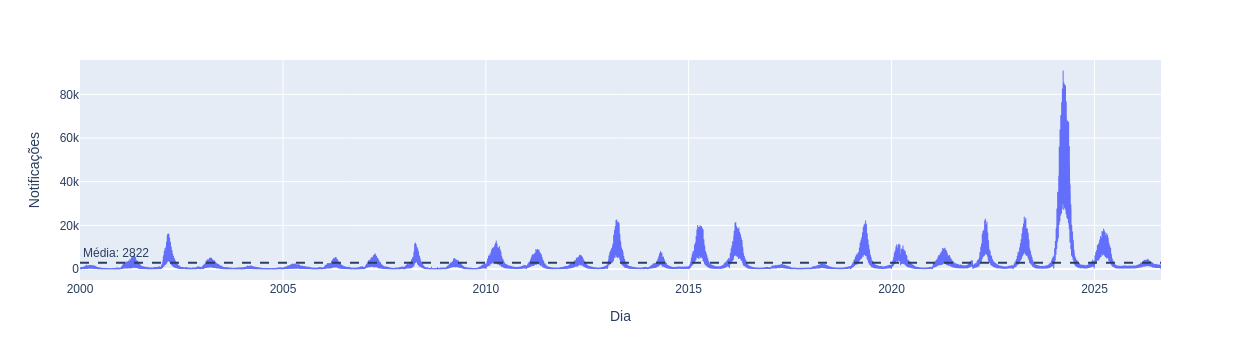

In [14]:
media = df_notificacoes['Notificações'].mean()

fig = px.line(
    df_notificacoes,
    x='Dia',
    y='Notificações'
)

fig.add_hline(
    y=media,
    line_dash='dash',
    annotation_text=f"Média: {media:.0f}",
    annotation_position="top left"
)

fig.update_traces(line=dict(width=1))

fig.show()

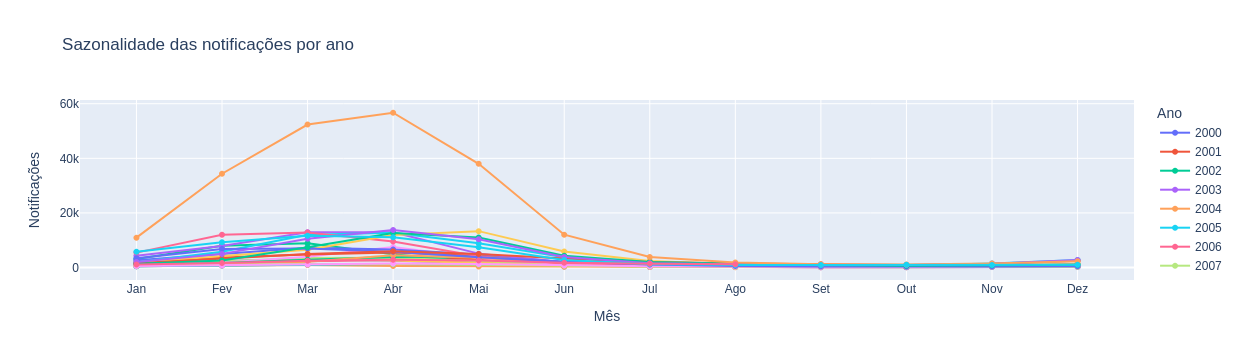

In [15]:
fig = px.line(
    df_sazonalidade,
    x="Mês",
    y="Notificações",
    color="Ano",
    markers=True,
    labels={
        "Mês": "Mês",
        "Notificações": "Notificações",
        "Ano": "Ano"
    },
    title="Sazonalidade das notificações por ano"
)

fig.update_layout(
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(1, 13)),
        ticktext=[
            "Jan", "Fev", "Mar", "Abr",
            "Mai", "Jun", "Jul", "Ago",
            "Set", "Out", "Nov", "Dez"
        ]
    )
)

fig.show()

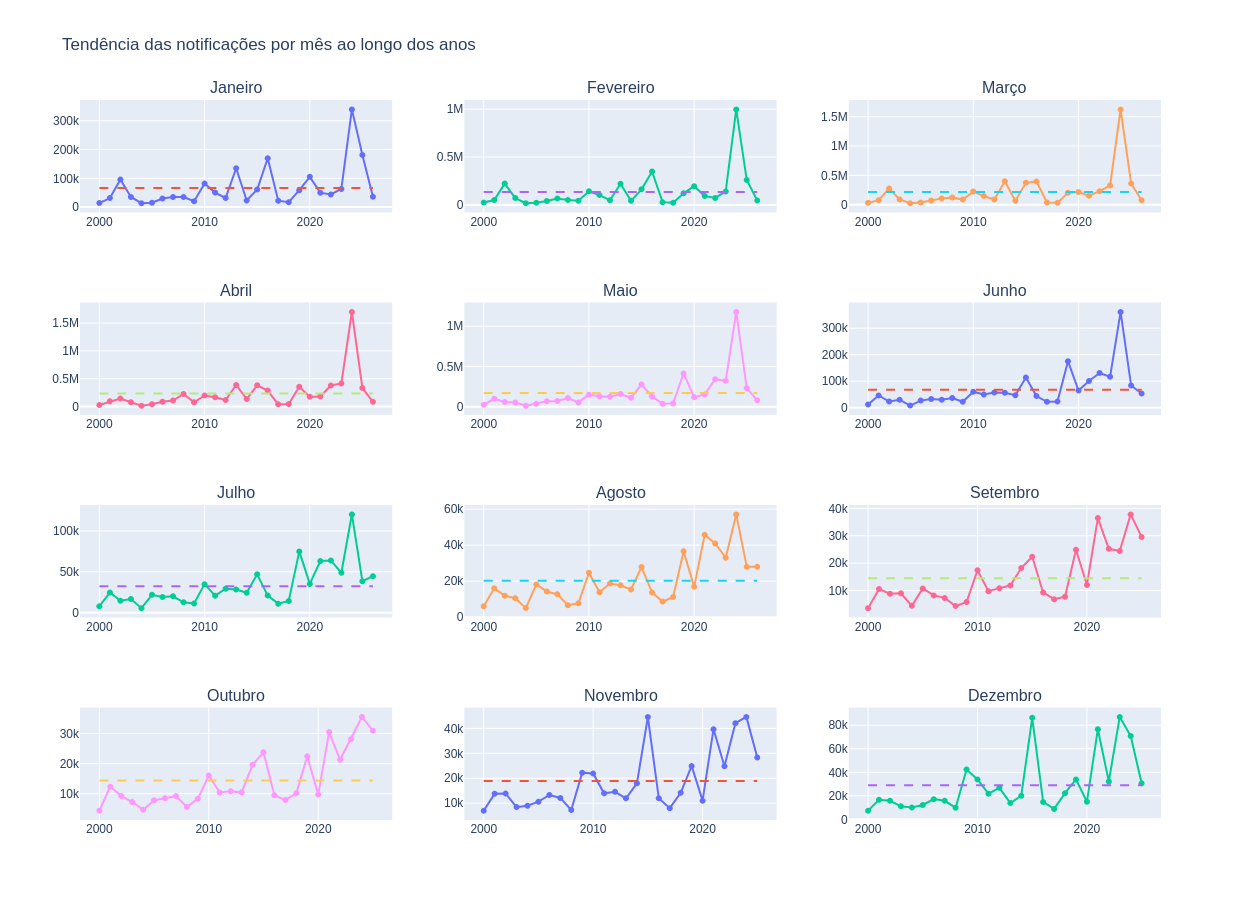

In [16]:
from plotly.subplots import make_subplots

# Criar ano e mês
df_notificacoes["Ano"] = df_notificacoes["Dia"].dt.year
df_notificacoes["Mês"] = df_notificacoes["Dia"].dt.month

# Soma das notificações de cada mês de cada ano
df_mensal = (
    df_notificacoes
    .groupby(["Ano", "Mês"])["Notificações"]
    .sum()
    .reset_index()
)

nomes_meses = [
    "Janeiro", "Fevereiro", "Março", "Abril",
    "Maio", "Junho", "Julho", "Agosto",
    "Setembro", "Outubro", "Novembro", "Dezembro"
]

# Criar 12 gráficos
fig = make_subplots(
    rows=4,
    cols=3,
    subplot_titles=nomes_meses
)

for mes in range(1, 13):

    dados = df_mensal[df_mensal["Mês"] == mes]

    # Média histórica daquele mês
    media = dados["Notificações"].mean()

    linha = go.Scatter(
        x=dados["Ano"],
        y=dados["Notificações"],
        mode="lines+markers",
        name="Notificações",
        showlegend=False
    )

    media_linha = go.Scatter(
        x=dados["Ano"],
        y=[media] * len(dados),
        mode="lines",
        name="Média",
        line=dict(dash="dash"),
        showlegend=False
    )

    linha_idx = (mes - 1) // 3 + 1
    coluna_idx = (mes - 1) % 3 + 1

    fig.add_trace(
        linha,
        row=linha_idx,
        col=coluna_idx
    )

    fig.add_trace(
        media_linha,
        row=linha_idx,
        col=coluna_idx
    )

fig.update_layout(
    title="Tendência das notificações por mês ao longo dos anos",
    height=900,
    width=1200
)

fig.show()

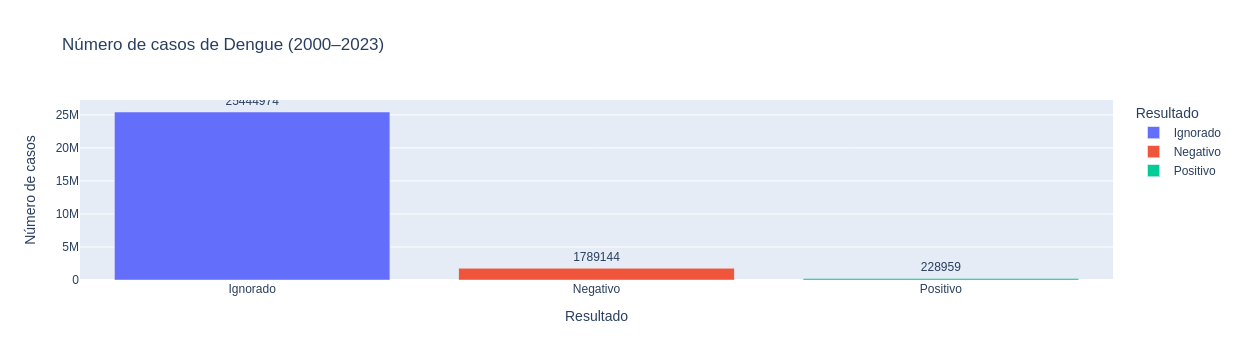

In [17]:
# Contagem dos resultados
dengue_counts = (
    classi_fin["DENGUE"]
    .value_counts()
    .reset_index()
)

dengue_counts.columns = ["Resultado", "Contagem"]

fig = px.bar(
    dengue_counts,
    x="Resultado",
    y="Contagem",
    text="Contagem",
    title="Número de casos de Dengue (2000–2023)",
    labels={
        "Contagem": "Número de casos",
        "Resultado": "Resultado"
    },
    color="Resultado"
)

fig.update_traces(textposition="outside")

fig.show()

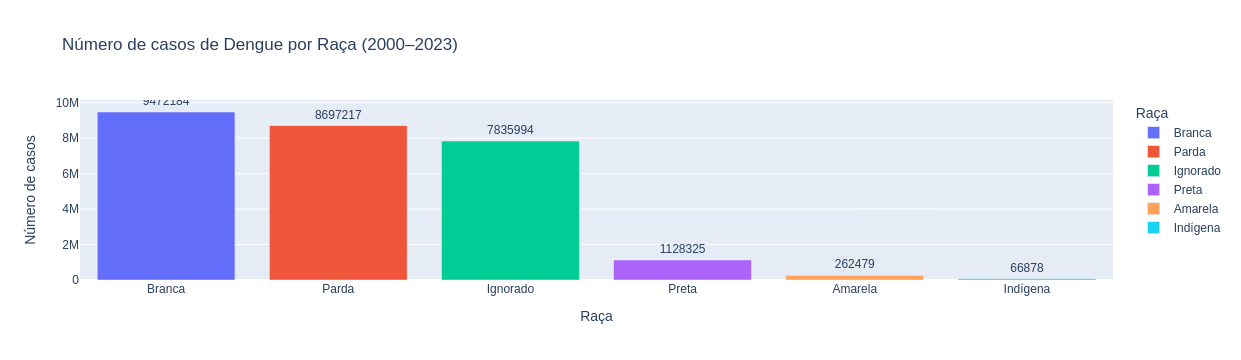

In [18]:
# Contagem dos resultados
raca_counts = (
    cs_raca["CS_RACA"]
    .value_counts()
    .reset_index()
)

raca_counts.columns = ["Raça", "Contagem"]

fig = px.bar(
    raca_counts,
    x="Raça",
    y="Contagem",
    text="Contagem",
    title="Número de casos de Dengue por Raça (2000–2023)",
    labels={
        "Contagem": "Número de casos",
        "Raça": "Raça"
    },
    color="Raça"
)

fig.update_traces(textposition="outside")

fig.show()

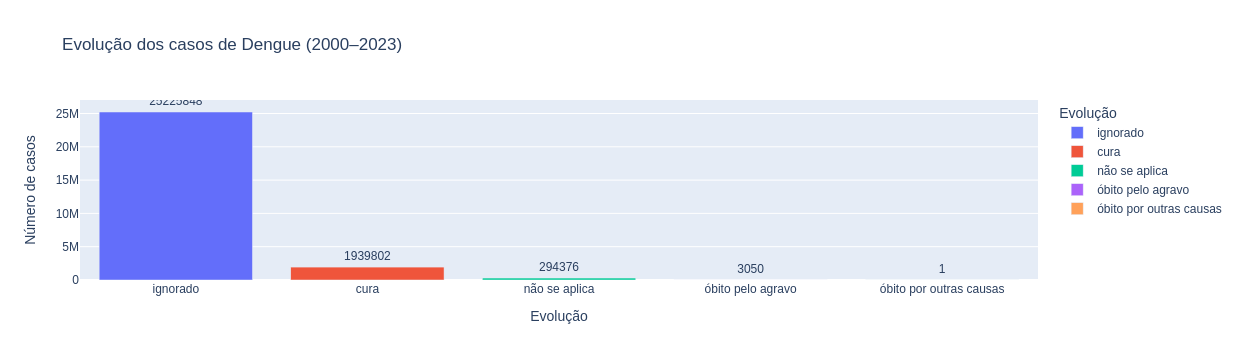

In [19]:
# Contagem dos resultados
evolucao_counts = (
    df_evolucao["CON_EVOLUC"]
    .value_counts()
    .reset_index()
)

evolucao_counts.columns = ["Evolução", "Contagem"]

fig = px.bar(
    evolucao_counts,
    x="Evolução",
    y="Contagem",
    text="Contagem",
    title="Evolução dos casos de Dengue (2000–2023)",
    labels={
        "Contagem": "Número de casos",
        "Evolução": "Evolução"
    },
    color="Evolução"
)

fig.update_traces(textposition="outside")

fig.show()

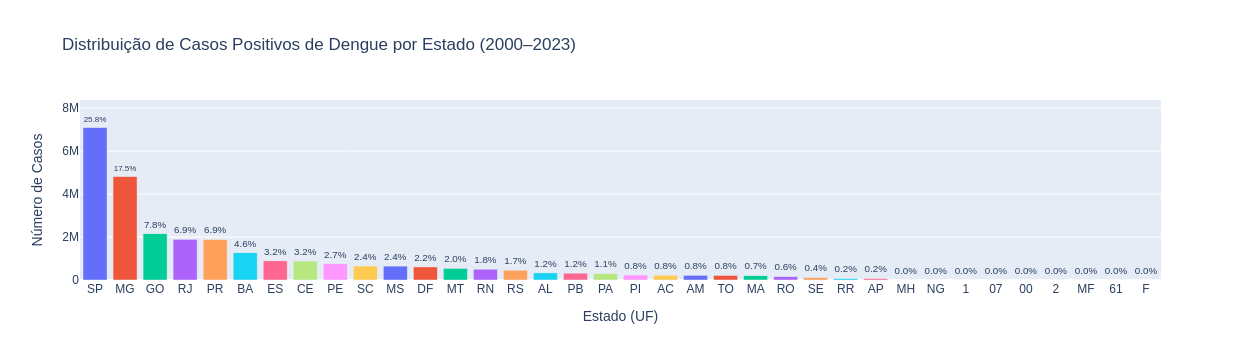

In [20]:
df_estado["Percentual"] = (
    df_estado["Notificações"]
    / df_estado["Notificações"].sum()
    * 100
)

df_estado = df_estado.sort_values(
    by="Notificações",
    ascending=False
)

fig = px.bar(
    df_estado,
    x="Estado",
    y="Notificações",
    color="Notificações",
    color_continuous_scale="Reds",
    text=df_estado["Percentual"].map(lambda x: f"{x:.1f}%"),
    title="Distribuição de Casos Positivos de Dengue por Estado (2000–2023)",
)

fig.update_traces(textposition="outside")

fig.update_layout(
    xaxis_title="Estado (UF)",
    yaxis_title="Número de Casos",
    showlegend=False
)

fig.show()

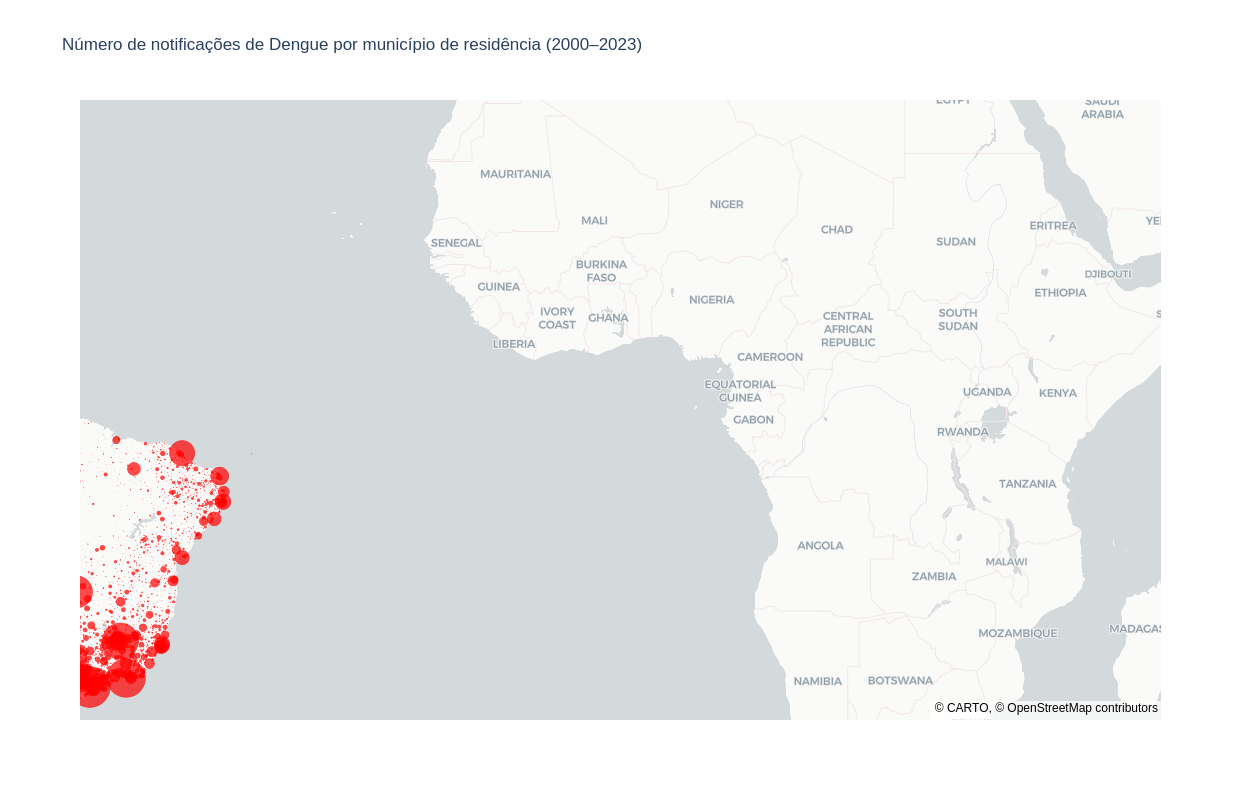

In [21]:
fig = px.scatter_map(
    df_municipio,
    lat="latitude",
    lon="longitude",
    size="Notificações",
    hover_name="name",
    size_max=30,
    zoom=3,
    map_style="carto-positron",
    title="Número de notificações de Dengue por município de residência (2000–2023)",
    height=800,
)

fig.update_traces(marker={"color": "red"})

fig.show()

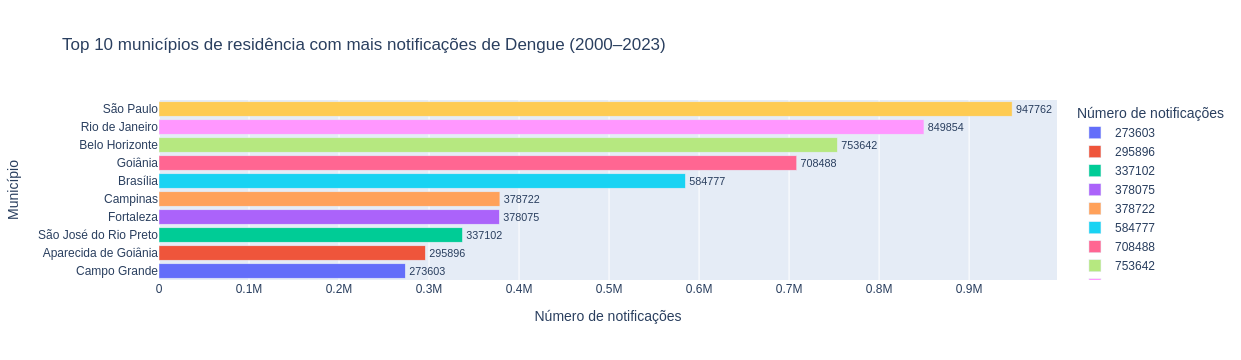

In [22]:
top_mun = df_municipio.sort_values(
    'Notificações',
    ascending=False
).head(10)

fig = px.bar(
    top_mun.sort_values('Notificações'),
    x='Notificações',
    y='name',
    orientation='h',
    text='Notificações',
    title='Top 10 municípios de residência com mais notificações de Dengue (2000–2023)',
    labels={
        'Notificações': 'Número de notificações',
        'name': 'Município'
    },
    color='Notificações'
)

fig.update_traces(textposition='outside')

fig.show()